# 2-d flow matching demo

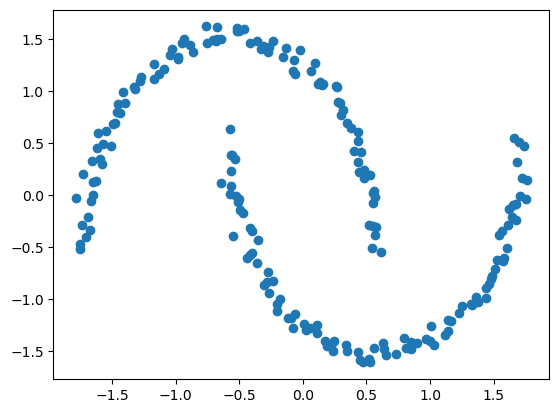

In [11]:
# Imports and load data

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import make_moons
from torch.utils.data import TensorDataset, DataLoader

def moons_dataset(n=1000):
    X, _ = make_moons(n_samples=n, random_state=42, noise=0.03)
    X[:, 0] = (X[:, 0] + 0.3) * 2 - 1
    X[:, 1] = (X[:, 1] + 0.3) * 3 - 1
    X -= X.mean(axis=0)
    X /= X.std(axis=0)
    return TensorDataset(torch.from_numpy(X.astype(np.float32)))

train_loader = DataLoader(moons_dataset(1000), batch_size=64, shuffle=True)
val_loader = DataLoader(moons_dataset(200), batch_size=64)

plt.scatter(val_loader.dataset.tensors[0][:,0], val_loader.dataset.tensors[0][:,1])

In [ ]:
# Define helper functions

def sample_t(batch_size):
    # Sample random t's with size batch size
    return torch.rand(batch_size)

def schedule(t):
    # Map t in [0,1] to our noise schedule?
    return t 

def add_noise(x, t):
    t = t.unsqueeze(1)
    return t * x + (1-t) * torch.randn_like(x)

In [ ]:
# Check the add noise function

In [ ]:
# Define a model 

class SimpleMLP(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=64, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


model = SimpleMLP(in_dim=2, hidden_dim=64, out_dim=2)
model

SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [ ]:



# train
model = SimpleModel()
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.MSE()
n_epochs = 5

for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for x in train_loader:
        optimizer.zero_grad()
        z = add_noise()
        x_hat = model(z)
        loss = criterion_ls(logits, labels)
        loss.backward()
        optimizer_ls.step()
        total_loss += loss.item() / len(train_loader)

    if (epoch + 1) % 5 == 0:
        model_ls.eval()
        with torch.no_grad():
            logits = model_ls(test_features.to(device))
            preds = logits.argmax(dim=1).cpu()
            acc = (preds == test_labels).float().mean()
        print(f'Epoch {epoch+1:2d}: train loss = {total_loss:.4f}, test acc = {acc:.4f}')